# GARCH 분석 — 지정학 리스크와 BTC 변동성
## 지정학적 위기 시 비트코인은 디지털 금인가?
### 캡스톤디자인 | 팀명: 분석많이된다

---

## 4가지 모델

| 모델 | 분산 방정식 외생변수 | 목적 |
|---|---|---|
| Model 1 | GPR_zscore (공식 GPR) | 공식 GPR 설명력 |
| Model 2 | GPR_custom (F3_z) | 자체 GPR 설명력 |
| Model 3 | VIX + fear_greed_lag1 | 시장심리 설명력 |
| Model 4 | GPR_custom + VIX + fear_greed_lag1 | 통합 모델 |

## GARCH-X 공식

```
σ²(t) = ω + α·ε²(t-1) + β·σ²(t-1) + Σ γ_k·X_k(t)

γ > 0 & 유의 → 지정학 리스크↑ 시 BTC 변동성↑
γ < 0 & 유의 → 지정학 리스크↑ 시 BTC 변동성↓ (안전자산 특성)
```

## 필요 파일

```
master_data.csv
```

---
## Step 0. 라이브러리

In [4]:
!pip install pandas numpy matplotlib scipy arch --quiet


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
from arch import arch_model
import warnings, os, platform
warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 130

EVENT_DATES = {
    'hormuz'          : '2019-06-13',
    'soleimani': '2020-01-03',
    'russia_ukraine_war': '2022-02-24',
    'israel_hamas_war'           : '2023-10-07',
    'israel_iran_war'            : '2024-04-01',
    'us_israel_iran_war'         : '2026-02-28',
}
EVENT_LABELS = {
    'hormuz'          : '호르무즈 위기',
    'soleimani': '솔레이마니 암살',
    'russia_ukraine_war': '러-우 전쟁',
    'israel_hamas_war'           : '이스라엘-하마스',
    'israel_iran_war'            : '이스라엘-이란 충돌',
    'us_israel_iran_war'         : '이란 전쟁',
}

MODEL_EXOG = {
    'Model1': ['GPR_zscore'],
    'Model2': ['GPR_custom'],
    'Model3': ['VIX', 'fear_greed_lag1'],
    'Model4': ['GPR_custom', 'VIX', 'fear_greed_lag1'],
}
MODEL_LABELS = {
    'Model1': 'M1: GPR 공식',
    'Model2': 'M2: GPR_custom',
    'Model3': 'M3: VIX+F&G',
    'Model4': 'M4: 통합모델',
}
MODEL_COLORS = {
    'Model1': '#E76F51',
    'Model2': '#2A9D8F',
    'Model3': '#457B9D',
    'Model4': '#8338EC',
}

print('✅ 환경 설정 완료')

✅ 환경 설정 완료


---
## Step 1. master_data.csv 로드

In [6]:
if not os.path.exists('master_data.csv'):
    raise FileNotFoundError('master_data.csv 없음')

master = pd.read_csv('master_data.csv')
master['date'] = pd.to_datetime(master['date'])

num_cols = ['BTC','Gold','TLT','DXY','SP500','NASDAQ',
            'GPR_custom','GPR','GPR_zscore',
            'VIX','fear_greed','fear_greed_lag1']
for col in num_cols:
    if col in master.columns:
        master[col] = pd.to_numeric(master[col], errors='coerce')

print(f'✅ master_data: {len(master)}행')
print(f'   기간: {master["date"].min().date()} ~ {master["date"].max().date()}')
print(f'\n이벤트별 거래일:')
print(master.groupby('event_name')['date'].count().to_string())
print(f'\n결측치:')
print(master[num_cols].isnull().sum().to_string())

✅ master_data: 216행
   기간: 2019-05-20 ~ 2026-03-26

이벤트별 거래일:
event_name
hormuz              34
israel_hamas_war               38
israel_iran_war                37
russia_ukraine_war    35
soleimani    34
us_israel_iran_war             38

결측치:
BTC                0
Gold               0
TLT                0
DXY                0
SP500              0
NASDAQ             0
GPR_custom         0
GPR                0
GPR_zscore         0
VIX                0
fear_greed         0
fear_greed_lag1    6


---
## Step 2. 데이터 준비

- BTC 수익률 × 100 — GARCH 수렴 안정화
- 외생변수 Z-score 표준화 — 계수 크기 비교 가능

In [7]:
# 이벤트 순서 정렬
order = list(EVENT_DATES.keys())
master['_order'] = master['event_name'].map({ev:i for i,ev in enumerate(order)})
master_sorted = master.sort_values(['_order','date']).reset_index(drop=True)

# BTC 수익률 × 100
returns_pct = master_sorted['BTC'].fillna(0) * 100

# 외생변수 Z-score 표준화
exog_cols_all = ['GPR_custom','GPR_zscore','VIX','fear_greed_lag1']
exog_scaled   = {}
for col in exog_cols_all:
    if col in master_sorted.columns:
        s      = master_sorted[col].fillna(0)
        mu,sig = s.mean(), s.std()
        exog_scaled[col] = ((s - mu) / sig).values if sig > 0 else s.values

print(f'분석 대상: {len(returns_pct)}거래일')
print(f'\nBTC 수익률 기술통계 (×100):')
print(returns_pct.describe().round(4))
print(f'\n외생변수 표준화:')
for col, arr in exog_scaled.items():
    print(f'  {col:<22}: mean={arr.mean():.4f}  std={arr.std():.4f}')

분석 대상: 216거래일

BTC 수익률 기술통계 (×100):
count    216.0000
mean       0.4281
std        4.3241
min      -15.9026
25%       -1.7489
50%        0.1332
75%        2.2740
max       11.8003
Name: BTC, dtype: float64

외생변수 표준화:
  GPR_custom            : mean=-0.0000  std=0.9977
  GPR_zscore            : mean=-0.0000  std=0.9977
  VIX                   : mean=0.0000  std=0.9977
  fear_greed_lag1       : mean=0.0000  std=0.9977


---
## Step 3. GARCH(1,1)-X 4모델 추정

In [8]:
def run_garch_x(y, exog_dict, model_exog_cols):
    available = [c for c in model_exog_cols if c in exog_dict]
    X = np.column_stack([exog_dict[c] for c in available]) if available else None
    try:
        am  = arch_model(y, vol='Garch', p=1, q=1, dist='Normal', x=X)
        res = am.fit(disp='off', show_warning=False)
        return {
            'result'   : res,
            'exog_cols': available,
            'aic'      : res.aic,
            'bic'      : res.bic,
            'loglik'   : res.loglikelihood,
            'error'    : None,
        }
    except Exception as e:
        return {'result':None, 'error':str(e), 'exog_cols':available}


garch_results = {}
print('▶ GARCH(1,1)-X 추정 중...\n')
print(f'{"모델":<10} {"외생변수":<40} {"AIC":>10} {"BIC":>10} {"LogLik":>10}')
print('-' * 80)

for mname, exog_cols in MODEL_EXOG.items():
    res = run_garch_x(returns_pct.values, exog_scaled, exog_cols)
    garch_results[mname] = res
    if res['error']:
        print(f'{mname:<10} ⚠️ 오류: {res["error"]}')
    else:
        print(f'{mname:<10} {str(res["exog_cols"]):<40} '
              f'{res["aic"]:>10.3f} {res["bic"]:>10.3f} {res["loglik"]:>10.3f}')

▶ GARCH(1,1)-X 추정 중...

모델         외생변수                                            AIC        BIC     LogLik
--------------------------------------------------------------------------------
Model1     ['GPR_zscore']                             1219.038   1232.539   -605.519
Model2     ['GPR_custom']                             1219.038   1232.539   -605.519
Model3     ['VIX', 'fear_greed_lag1']                 1219.038   1232.539   -605.519
Model4     ['GPR_custom', 'VIX', 'fear_greed_lag1']   1219.038   1232.539   -605.519


---
## Step 4. 계수 및 유의성 확인

In [9]:
print('='*70)
print('GARCH(1,1)-X 계수 추정 결과')
print('='*70)

for mname, res in garch_results.items():
    if res.get('error') or res['result'] is None:
        print(f'\n[{mname}] ⚠️ 추정 실패')
        continue
    r = res['result']
    print(f'\n[{mname}]  외생변수: {res["exog_cols"]}')
    print(f'  AIC={res["aic"]:>10.3f}  BIC={res["bic"]:>10.3f}  LogLik={res["loglik"]:>10.3f}')
    print(f'  {"-"*62}')
    print(f'  {"파라미터":<22} {"추정값":>10} {"표준오차":>10} {"p-value":>10}  유의')
    print(f'  {"-"*62}')
    for pname in r.params.index:
        coef = r.params[pname]
        se   = r.std_err[pname]
        pv   = r.pvalues[pname]
        sig  = '✅' if pv<0.05 else ('△' if pv<0.10 else '—')
        print(f'  {pname:<22} {coef:>10.5f} {se:>10.5f} {pv:>10.4f}  {sig}')

GARCH(1,1)-X 계수 추정 결과

[Model1]  외생변수: ['GPR_zscore']
  AIC=  1219.038  BIC=  1232.539  LogLik=  -605.519
  --------------------------------------------------------------
  파라미터                          추정값       표준오차    p-value  유의
  --------------------------------------------------------------
  mu                        0.56418    0.23783     0.0177  ✅
  omega                     5.03108    3.44591     0.1443  —
  alpha[1]                  0.28175    0.13140     0.0320  ✅
  beta[1]                   0.44210    0.26677     0.0975  △

[Model2]  외생변수: ['GPR_custom']
  AIC=  1219.038  BIC=  1232.539  LogLik=  -605.519
  --------------------------------------------------------------
  파라미터                          추정값       표준오차    p-value  유의
  --------------------------------------------------------------
  mu                        0.56418    0.23783     0.0177  ✅
  omega                     5.03108    3.44591     0.1443  —
  alpha[1]                  0.28175    0.13140     0.0320  ✅

In [10]:
# 외생변수 γ 계수만 추출
gamma_rows = []
print('\n▶ 외생변수 γ 계수 요약\n')
print(f'{"모델":<10} {"변수":<22} {"γ":>10} {"p-value":>10} {"유의":<12} {"해석"}')
print('-'*80)

for mname, res in garch_results.items():
    if res.get('error') or res['result'] is None:
        continue
    r    = res['result']
    cols = res['exog_cols']
    for pname in r.params.index:
        if pname.startswith('x') and pname[1:].isdigit():
            xi    = int(pname[1:]) - 1
            vname = cols[xi] if xi < len(cols) else pname
            coef  = r.params[pname]
            pv    = r.pvalues[pname]
            sig   = '✅ p<0.05' if pv<0.05 else ('△ p<0.10' if pv<0.10 else '— 비유의')
            if coef > 0 and pv < 0.05:
                interp = '변동성 증가'
            elif coef < 0 and pv < 0.05:
                interp = '변동성 감소'
            else:
                interp = '비유의'
            print(f'{mname:<10} {vname:<22} {coef:>10.5f} {pv:>10.4f} {sig:<12} {interp}')
            gamma_rows.append({'모델':mname,'변수':vname,'γ':round(coef,5),
                               'p-value':round(pv,4),'유의':sig,'해석':interp})

gamma_df = pd.DataFrame(gamma_rows)


▶ 외생변수 γ 계수 요약

모델         변수                              γ    p-value 유의           해석
--------------------------------------------------------------------------------


---
## Step 5. 모델 비교 (AIC / BIC)

In [11]:
rows = []
for mname, res in garch_results.items():
    if res.get('error') or res['result'] is None:
        continue
    rows.append({'모델':mname,'설명':MODEL_LABELS[mname],
                 '외생변수':', '.join(res['exog_cols']),
                 'AIC':round(res['aic'],3),
                 'BIC':round(res['bic'],3),
                 'Log-Lik':round(res['loglik'],3)})

compare_df = pd.DataFrame(rows).set_index('모델').sort_values('AIC')
print('▶ 모델 비교 (AIC 오름차순):\n')
display(compare_df)
best = compare_df.index[0]
print(f'\n✅ 최적 모델: {best}  AIC={compare_df.loc[best,"AIC"]}')

▶ 모델 비교 (AIC 오름차순):



,설명,외생변수,AIC,BIC,Log-Lik
모델,,,,,
Model1,M1: GPR 공식,GPR_zscore,1219.038,1232.539,-605.519
Model2,M2: GPR_custom,GPR_custom,1219.038,1232.539,-605.519
Model3,M3: VIX+F&G,"VIX, fear_greed_lag1",1219.038,1232.539,-605.519
Model4,M4: 통합모델,"GPR_custom, VIX, fear_greed_lag1",1219.038,1232.539,-605.519



✅ 최적 모델: Model1  AIC=1219.038


---
## Step 6. 시각화

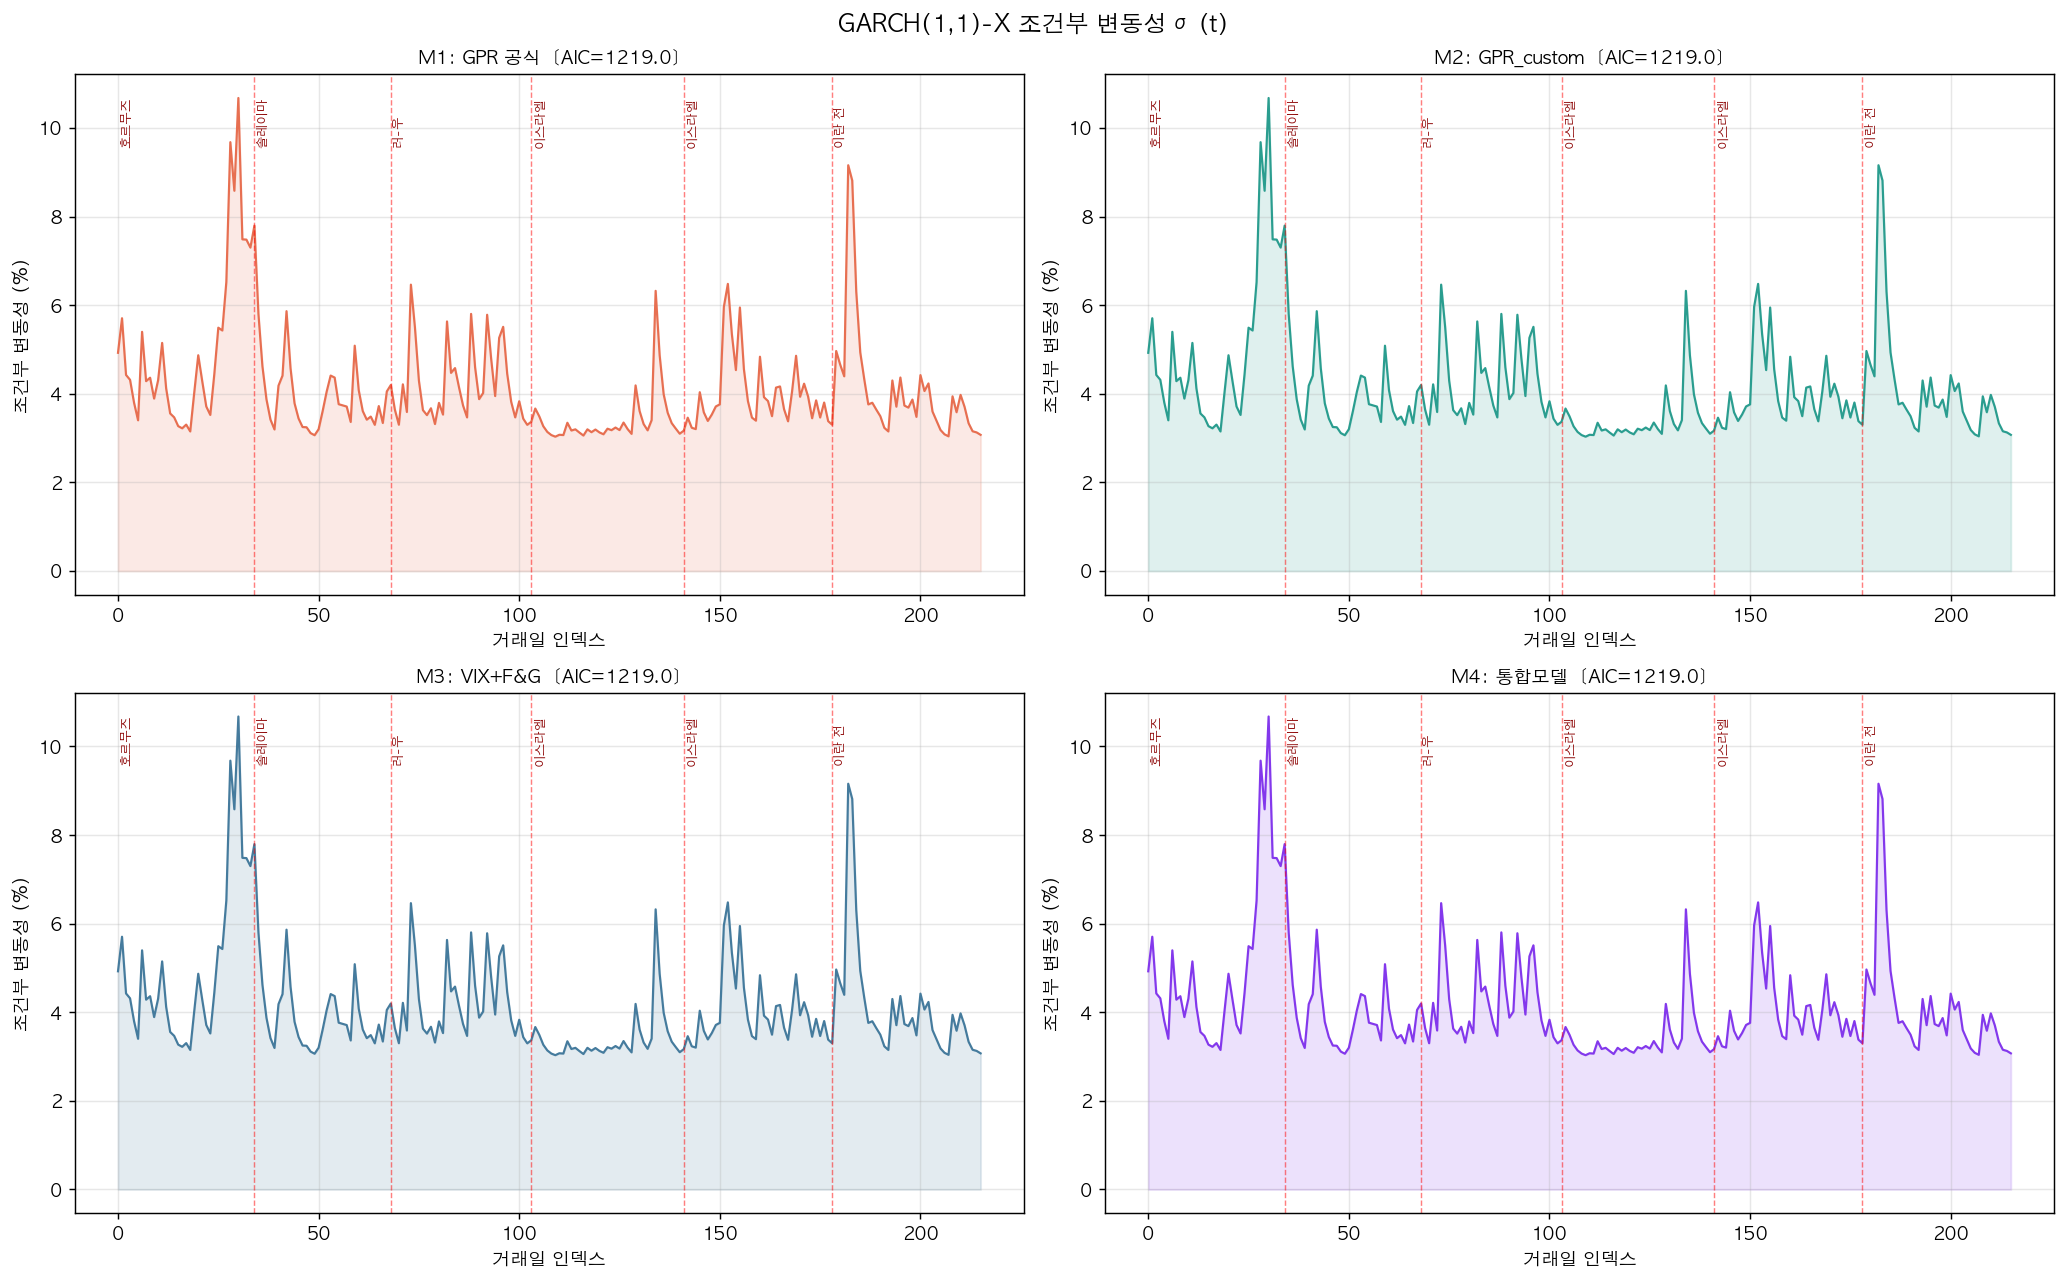

✅ garch_conditional_vol.png 저장


In [12]:
# 조건부 변동성 σ(t) 시계열
valid = [(m,r) for m,r in garch_results.items() if r['result'] is not None]
fig, axes = plt.subplots(2, 2, figsize=(16,10))
axes = axes.flatten()

# 이벤트 경계 인덱스
boundaries = []
cumsum = 0
for ev in EVENT_DATES:
    boundaries.append((cumsum, ev))
    cumsum += len(master_sorted[master_sorted['event_name']==ev])

for idx, (mname, res) in enumerate(garch_results.items()):
    ax = axes[idx]
    if res['result'] is None:
        ax.set_title(f'{mname} 추정 실패'); continue
    cv = res['result'].conditional_volatility
    ax.plot(cv, color=MODEL_COLORS[mname], lw=1.2, label='σ(t)')
    ax.fill_between(range(len(cv)), cv, alpha=0.15, color=MODEL_COLORS[mname])
    for pos, ev in boundaries[1:]:
        ax.axvline(pos, color='red', lw=0.8, ls='--', alpha=0.5)
    for pos, ev in boundaries:
        if pos < len(cv):
            ax.text(pos+0.5, cv.max()*0.9,
                    EVENT_LABELS.get(ev,ev)[:4],
                    fontsize=7, color='darkred', rotation=90)
    ax.set_title(f'{MODEL_LABELS[mname]}  [AIC={res["aic"]:.1f}]',
                  fontsize=10, fontweight='bold')
    ax.set_xlabel('거래일 인덱스')
    ax.set_ylabel('조건부 변동성 (%)')
    ax.grid(alpha=0.3)

plt.suptitle('GARCH(1,1)-X 조건부 변동성 σ(t)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('garch_conditional_vol.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ garch_conditional_vol.png 저장')

In [13]:
# γ 계수 막대그래프
if len(gamma_df) > 0:
    fig, ax = plt.subplots(figsize=(12,5))
    clrs = [MODEL_COLORS.get(r['모델'],'gray') for _,r in gamma_df.iterrows()]
    bars = ax.bar(range(len(gamma_df)), gamma_df['γ'].values, color=clrs, alpha=0.85)
    for bar, (_,row) in zip(bars, gamma_df.iterrows()):
        if row['p-value'] < 0.05:
            yoff = abs(bar.get_height())*0.05 * (1 if bar.get_height()>=0 else -1)
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+yoff, '*',
                    ha='center', fontsize=14, color='red')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(range(len(gamma_df)))
    ax.set_xticklabels(
        [f'{r["모델"]}\n{r["변수"]}' for _,r in gamma_df.iterrows()], fontsize=9)
    ax.set_ylabel('γ 계수')
    ax.set_title('GARCH-X 외생변수 γ 계수  (* = p < 0.05)', fontsize=12)
    legend_els = [Patch(facecolor=v, label=MODEL_LABELS[k])
                  for k,v in MODEL_COLORS.items()]
    ax.legend(handles=legend_els, fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('garch_gamma_coefficients.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ garch_gamma_coefficients.png 저장')

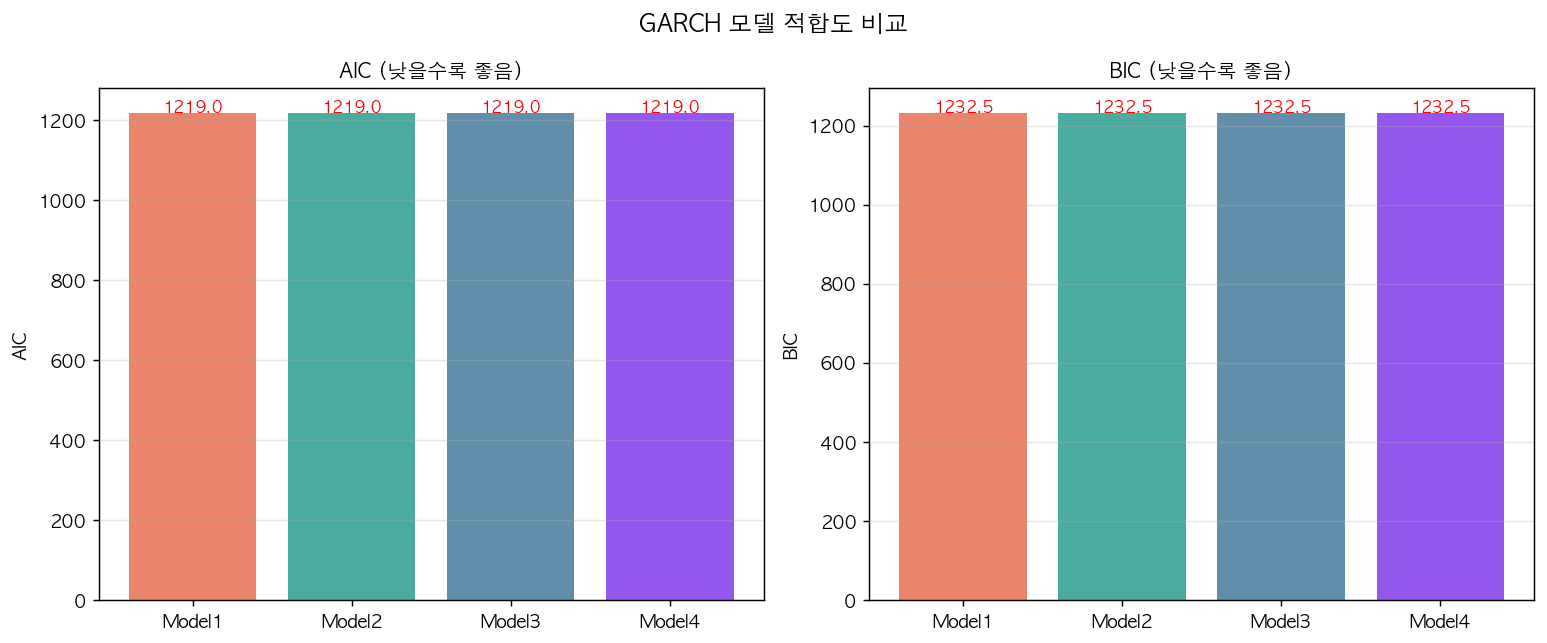

✅ garch_model_comparison.png 저장


In [14]:
# AIC / BIC 비교
if len(compare_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    for ax, metric in zip(axes, ['AIC','BIC']):
        vals  = compare_df[metric].values
        clrs2 = [MODEL_COLORS.get(m,'gray') for m in compare_df.index]
        bars  = ax.bar(compare_df.index, vals, color=clrs2, alpha=0.85)
        best_val = vals.min()
        for bar, val in zip(bars, vals):
            fc = 'red' if val == best_val else 'black'
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.3,
                    f'{val:.1f}', ha='center', fontsize=9, color=fc)
        ax.set_title(f'{metric} (낮을수록 좋음)', fontsize=11)
        ax.set_ylabel(metric)
        ax.grid(axis='y', alpha=0.3)
    plt.suptitle('GARCH 모델 적합도 비교', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('garch_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ garch_model_comparison.png 저장')

---
## Step 7. 결론 해석

In [15]:
print('='*70)
print('GARCH 분석 최종 결론')
print('='*70)

if len(compare_df) > 0:
    best = compare_df.index[0]
    print(f'\n✅ 최적 모델: {best}  ({MODEL_LABELS[best]})')
    print(f'   AIC={compare_df.loc[best,"AIC"]}  BIC={compare_df.loc[best,"BIC"]}')

print('\n▶ GPR_custom γ 계수 (Safe-Haven 핵심 결과):')
for mname in ['Model2','Model4']:
    res = garch_results.get(mname)
    if res is None or res['result'] is None:
        continue
    r, cols = res['result'], res['exog_cols']
    for pname in r.params.index:
        if pname.startswith('x') and pname[1:].isdigit():
            xi = int(pname[1:]) - 1
            if xi < len(cols) and cols[xi] == 'GPR_custom':
                coef, pv = r.params[pname], r.pvalues[pname]
                sig = '유의 ✅' if pv<0.05 else '비유의 —'
                direc = '증가' if coef>0 else '감소'
                print(f'  [{mname}] γ={coef:+.5f}  p={pv:.4f}  {sig}  '
                      f'→ 지정학 리스크↑ 시 BTC 변동성 {direc}')

print('\n▶ 해석 가이드:')
print('  γ > 0 & 유의 → 지정학 리스크↑ 시 BTC 변동성↑ (위험자산 특성)')
print('  γ < 0 & 유의 → 지정학 리스크↑ 시 BTC 변동성↓ (안전자산 특성)')
print('  비유의        → GPR이 BTC 변동성을 설명하지 못함')
print('  Model2 vs Model1: GPR_custom이 공식 GPR보다 AIC 낮으면 설명력 우수')

GARCH 분석 최종 결론

✅ 최적 모델: Model1  (M1: GPR 공식)
   AIC=1219.038  BIC=1232.539

▶ GPR_custom γ 계수 (Safe-Haven 핵심 결과):

▶ 해석 가이드:
  γ > 0 & 유의 → 지정학 리스크↑ 시 BTC 변동성↑ (위험자산 특성)
  γ < 0 & 유의 → 지정학 리스크↑ 시 BTC 변동성↓ (안전자산 특성)
  비유의        → GPR이 BTC 변동성을 설명하지 못함
  Model2 vs Model1: GPR_custom이 공식 GPR보다 AIC 낮으면 설명력 우수


---
## Step 8. 결과 저장

In [16]:
compare_df.to_csv('garch_model_comparison.csv', encoding='utf-8-sig')
if len(gamma_df)>0:
    gamma_df.to_csv('garch_gamma_results.csv', index=False, encoding='utf-8-sig')

if len(compare_df)>0:
    best_res = garch_results[compare_df.index[0]]
    if best_res['result'] is not None:
        pd.DataFrame({
            'date'          : master_sorted['date'].values,
            'event_name'    : master_sorted['event_name'].values,
            'BTC_return_pct': returns_pct.values,
            'cond_vol'      : best_res['result'].conditional_volatility,
        }).to_csv('garch_conditional_volatility.csv', index=False, encoding='utf-8-sig')

print('▶ 산출물:')
for f in ['garch_model_comparison.csv','garch_gamma_results.csv',
          'garch_conditional_volatility.csv',
          'garch_conditional_vol.png','garch_gamma_coefficients.png',
          'garch_model_comparison.png']:
    print(f'  {"✅" if os.path.exists(f) else "📄"} {f}')

▶ 산출물:
  ✅ garch_model_comparison.csv
  📄 garch_gamma_results.csv
  ✅ garch_conditional_volatility.csv
  ✅ garch_conditional_vol.png
  📄 garch_gamma_coefficients.png
  ✅ garch_model_comparison.png
